# 卷积 Convolution


这是陈硕写的《数字信号处理入门实验》的第二章第1个实验，复习卷积相关知识，实验的主要目的是用卷积来模拟某些场景（大礼堂、隧道）中说话的音效。
最新版网址： https://github.com/chenshuo/notes/tree/master/notebooks/dsp

预览运行结果： http://chenshuo.github.io/labs/lab/index.html?path=dsp/2a-convolution.ipynb  或者 [Google Colab](https://colab.research.google.com/github/chenshuo/notes/blob/master/notebooks/dsp/2a-convolution.ipynb)

本节内容视频讲解：https://youtu.be/79YKlXecF7w 国内：[卷积](https://www.bilibili.com/video/BV1ng41117wB)


如果在 Jupyter-lite 下运行，需要安装：

In [ ]:
%pip install -q ipywidgets

首先引入 NumPy、SciPy.signal、Matplotlib 等必要的库。

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

from ipywidgets import interact

np.set_printoptions(suppress=True)

查看一下 Jupyter 的版本。

In [ ]:
!jupyter --version

所谓“线性时不变系统（LTI）”有两个基本属性：

* 线性 linear，即满足叠加原理(superposition principle)。就是说如果系统输入 $\boldsymbol x_1$ 信号时的输出是 $\boldsymbol y_1$，输入 $\boldsymbol x_2$ 信号时的输出是 $\boldsymbol y_2$ ，那么如果输入信号是 $\boldsymbol x_1 + \boldsymbol x_2$，那么输出信号是 $\boldsymbol y_1 + \boldsymbol y_2$。这也意味着 输入信号变成 $a \boldsymbol x_1$ 时输出信号是 $a \boldsymbol y_1$。
* 时不变性 (time invariant)，也叫定常性，即同样的一份输入信号 $\boldsymbol x$，今天和明天的输出 $\boldsymbol y$ 是一样的，只是延迟了一天。就是说如果系统输入 $x[n]$ 信号时的输出是 $ y[n]$当输入延迟 k 个时间单位 $x[n-k]$，那么输出也响应地延迟为 $y[n-k]$。

有了这两条属性，一个 LTI 系统可以完全由其冲击响应来定义，因为可以把输入信号 $x[n]$ 分解为多个单位冲击信号 $\delta[n]$ 的平移与倍数的叠加，而相应的输出信号则是单位冲击响应 $h[n]$ 的平移与倍数的叠加，这个过程用卷积来描述较为方便。

对于 LTI （线性时不变）系统来说，输出信号 $\boldsymbol y$ 是输入信号 $\boldsymbol x$ 与冲击响应 $\boldsymbol h$ 的卷积:

$Output = Convolve(Input, ImpulseResponse)$

对于 CT （连续时间）系统而言，卷积是卷积积分，表达式从略。

对于 DT （离散时间）系统而言，卷积就是求和 $y[n]=\displaystyle\sum_{k} x[k]\cdot h[n-k] = \sum_{k} x[n-k]\cdot h[k]$，
其中 $h[n]$ 是单位冲击响应序列。



举一个简单的例子，

$y[n] = 2x[n] + 3x[n-1] + 4x[n-2]$

In [2]:
%load_ext tikzmagic

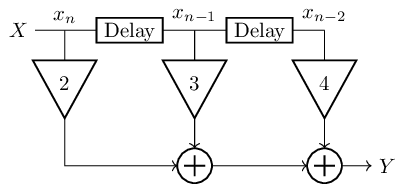

In [3]:
%%tikz -ct

\tikzset{european resistors};
\draw (0, 0) node [left] {$X$}
  to [short] ++(0.5, 0) coordinate (In) node [above] {$x_n$}
  to [R=Delay,label distance=-13pt] ++(2.2, 0) coordinate (X1) node [above] {$x_{n-1}$}
  to [R=Delay,label distance=-13pt] ++(2.2, 0) coordinate (X2) node [above] {$x_{n-2}$};

\draw [->] (X1) to [amp,n=M1] ++(0, -2) node [scale=0.6, adder, anchor=n] (A1) {};
\draw [->] (X2) to [amp,n=M2] ++(0, -2) node [scale=0.6, adder, anchor=n] (A2) {};
\draw [->] (In) to [amp,n=M0] ++(0, -2) to (In |- A1) to (A1.w);
\draw [->] (A1.e) to (A2.w);
\draw [->] (A2.e) to [short] ++(0.5, 0) node [right] {$Y$};
\draw (M0) ++(0, 0.1) node [] {$2$};
\draw (M1) ++(0, 0.1) node [] {$3$};
\draw (M2) ++(0, 0.1) node [] {$4$};


$\boldsymbol h = [h_0,\ h_1,\ h_2] = [2, 3, 4]$ 和 $\boldsymbol x = [x_0,\ x_1,\ x_2,\ x_3]$

$y[n]=h[n]*x[n]$ 也可以写成矩阵的形式：

$\boldsymbol y =
\begin{bmatrix}
y_0 \\ y_1 \\ y_2 \\ y_3 \\ y_4 \\ y_5
\end{bmatrix} = 
\begin{bmatrix}
2 & 0 & 0 & 0 \\
3 & 2 & 0 & 0 \\
4 & 3 & 2 & 0 \\
0 & 4 & 3 & 2 \\
0 & 0 & 4 & 3 \\
0 & 0 & 0 & 4 \\
\end{bmatrix}
\begin{bmatrix}
x_0 \\ x_1 \\ x_2 \\ x_3
\end{bmatrix} = H\boldsymbol x
$

这样卷积的一些性质（线性、分配律）也就一目了然了。

## LibROSA


LibROSA 目前无法在 Jupyter-lite 中运行。

In [12]:
import librosa as rosa
import librosa.display
from IPython.display import Audio
rosa.version.show_versions()

INSTALLED VERSIONS
------------------
python: 3.13.5 (main, Jun 25 2025, 18:55:22) [GCC 14.2.0]

librosa: 0.11.0

audioread: installed, no version number available
numpy: 2.4.4
scipy: 1.17.1
sklearn: 1.8.0
joblib: 1.5.3
decorator: 5.2.1
numba: 0.65.1
soundfile: 0.13.1
pooch: v1.9.0
soxr: 1.1.0
typing_extensions: installed, no version number available
lazy_loader: 0.5
msgpack: 1.1.2

numpydoc: None
sphinx: None
sphinx_rtd_theme: None
matplotlib: 3.10.9
sphinx_multiversion: None
sphinx_gallery: None
mir_eval: None
ipython: None
sphinxcontrib.rsvgconverter: None
pytest: None
pytest_mpl: None
pytest_cov: None
samplerate: None
resampy: None
presets: None
packaging: 26.1


Acoustic Impulse Responses

* [Allen Downey - ThinkDSP](https://github.com/AllenDowney/ThinkDSP)
  * Execrise 10.2 _Simulate the sound of your recording in the space where the impulse response was measured, ..._
* [Allen Downey - Introduction to Digital Signal Processing - PyCon 2018](https://www.youtube.com/watch?v=SrJq2AzXZME)
* [Basic Sound Processing in Python | SciPy 2015 | Allen Downey](https://www.youtube.com/watch?v=0ALKGR0I5MA) 15 min

A room (e.g. concert hall) behaves like a LTI system for sound.
Here _Time-Invariant_ is assumed.

 * [Open Air Library](https://www.openairlib.net/) - acoustic impulse responses
 * [PyRoomAcoustics](https://pyroomacoustics.readthedocs.io/en/pypi-release/index.html) - Room Acoustics Simulation

Librosa

* https://medium.com/@patrickbfuller/librosa-a-python-audio-libary-60014eeaccfb
* https://www.youtube.com/watch?v=MhOdbtPhbLU


In [3]:
rosa.util.list_examples()

AVAILABLE EXAMPLES
--------------------------------------------------------------------
brahms    	Brahms - Hungarian Dance #5
choice    	Admiral Bob - Choice (drum+bass)
fishin    	Karissa Hobbs - Let's Go Fishin'
humpback  	Glacier Bay 60-second clip humpback whale song November 2020
libri1    	Ashiel Mystery - A Detective Story, chapter 2, narrated by Garth Comira
libri2    	The Age of Chivalry / Chapter 18: Perceval / Read by Anders Lankford
libri3    	Sense and Sensibility / Chapter 18 / Jane Austen / Read by Heather Barnett
nutcracker	Tchaikovsky - Dance of the Sugar Plum Fairy
pistachio 	The Piano Lady - Pistachio Ice Cream Ragtime
robin     	Bird Whistling, Robin, Single, 13.wav / InspectorJ
sweetwaltz	Setuniman - Sweet Waltz
trumpet   	Mihai Sorohan - Trumpet loop
vibeace   	Kevin MacLeod - Vibe Ace


本节的实验会用到本地音频文件，因此无法在 Colab 上直接运行。

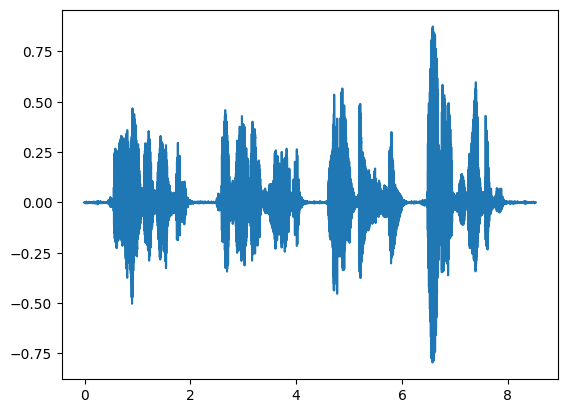

In [5]:
x, sr = rosa.load('data/poem.ogg')
t = np.arange(len(x)) / sr
plt.plot(t, x)

Audio(x, rate=sr, normalize=False)

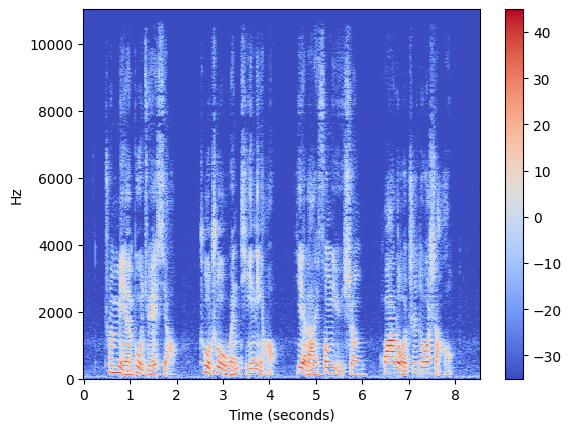

In [6]:
f = rosa.stft(x)
rosa.display.specshow(rosa.amplitude_to_db(np.abs(f)), sr=sr, y_axis='hz', x_axis='s')
plt.colorbar()

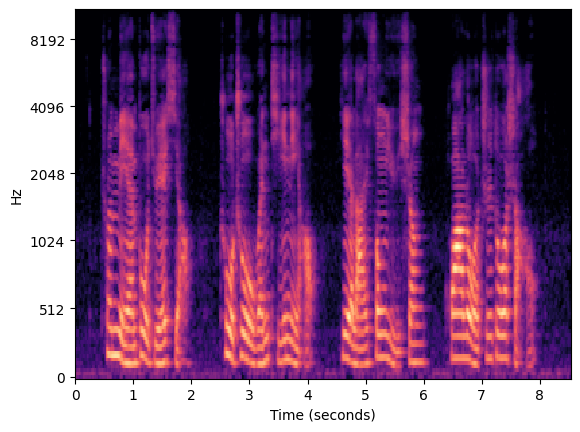

In [7]:
spec = rosa.feature.melspectrogram(y=x, sr=sr)
db_spec = rosa.power_to_db(spec, ref=np.max)
rosa.display.specshow(db_spec,y_axis='mel', x_axis='s', sr=sr)
# plt.colorbar()

## Innocent Railway Tunnel

https://www.openair.hosted.york.ac.uk/?page_id=525

这是一个过去的火车隧道的冲击响应。

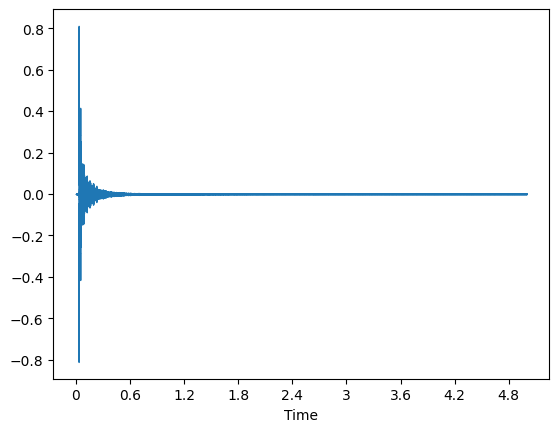

In [8]:
h1, sr = rosa.load('data/middle_tunnel_1way_mono.flac')

rosa.display.waveshow(y=h1, sr=sr)
Audio(h1, rate=sr, normalize=False)

通过将语音信号与隧道的冲击响应相卷积，我们就模拟了这这个隧道中说话的效果。

In [9]:
y1 = signal.oaconvolve(x, h1, mode='full')
print("%.3f sec" % (len(y1)/sr))
Audio(y1, rate=sr, normalize=True)

13.522 sec


Text(0.5, 1.0, 'Original')

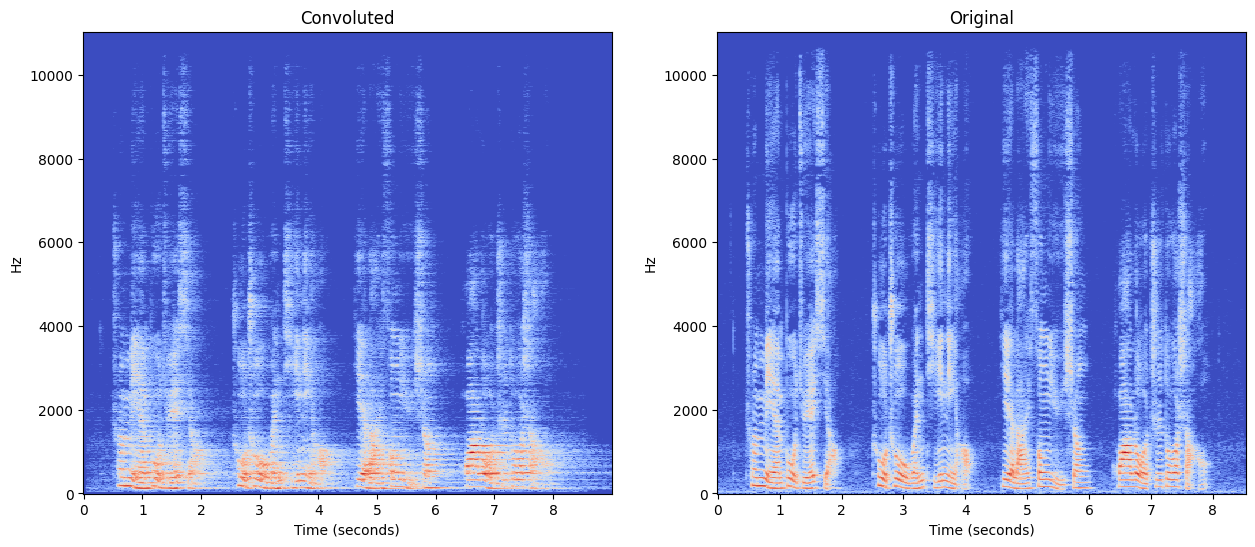

In [10]:
plt.figure(figsize=(15,6))

plt.subplot(121)
f1 = rosa.stft(y1[0:sr*9])
rosa.display.specshow(rosa.amplitude_to_db(np.abs(f1)), sr=sr, y_axis='hz', x_axis='s')
plt.title('Convoluted')

plt.subplot(122)
rosa.display.specshow(rosa.amplitude_to_db(np.abs(f)), sr=sr, y_axis='hz', x_axis='s')
plt.title('Original')

**练习**：用英国 York 大学 Central Hall 的冲击响应重做以上实验。

https://www.openair.hosted.york.ac.uk/?page_id=435

## Deconvolution

https://en.wikipedia.org/wiki/Deconvolution

One of Prof. Alan V. Oppenheim's faviourite examples: Digital restoration of Enrico Caruso's recordings by Thomas Stockham. 1975 paper: "Blind deconvolution through Digital Signal Processing".

* [MIT RES.6-007 Signals ans Systems, 1987](https://youtu.be/KJnAy6hzetw?t=760)
* [MIT RES.6-008 Digital Signal Processing, 1975](https://youtu.be/rkvEM5Y3N60?t=338)
* [MITx 6.341x Discrete-Time Signal Processing, 2016](https://learning.edx.org/course/course-v1:MITx+6.341x_2+2T2016/block-v1:MITx+6.341x_2+2T2016+type@sequential+block@Enrichment_lecture_How_Caruso_Lost_His_Orchestra/block-v1:MITx+6.341x_2+2T2016+type@vertical+block@Enrichment_Lecture_2_Video_3)

